# Figure: Effect of Multiple Trials

This notebook reproduces "Figure 3: **Results: Multiple Trials**" from the manuscript.

In [7]:
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import numpy as np
import pandas as pd
sys.path.append("..")

from experiments.config import experiments
from src.utils import to_list_of_dicts

In [8]:
import matplotlib as mpl
from matplotlib.colors import to_rgba

mpl.rcParams['lines.linewidth'] = 2.5
mpl.rcParams['xtick.labelsize'] = 10
mpl.rcParams['ytick.labelsize'] = 10
mpl.rcParams["axes.labelsize"] = 16
mpl.rcParams['legend.fontsize'] = 15
mpl.rcParams['axes.titlesize'] = 17
mpl.rcParams['text.usetex'] = True
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [9]:
def load_result(i, experiment):
    save_dir = f"../experiments/out/{experiment}"
    with open(os.path.join(save_dir, f"{i:03d}.json"), "r") as f:
        return json.load(f)

def get_experiment_dataframe(experiment):
    save_dir = f"../experiments/out/{experiment}"
    lst_ = to_list_of_dicts(experiments[experiment])

    lst = []
    for i in range(len(lst_)):
        lst.append(lst_[i])

    df = pd.DataFrame(lst).reset_index()
    return df

## Concatenation of trials estimate

In [10]:
from matplotlib.patches import Patch

alpha = 0.4
colors = {
    "FOBI": ("black", to_rgba("black", alpha=alpha)),
    "JADE": ("cadetblue", to_rgba("cadetblue", alpha=alpha)),
    "MultiICA": ("chocolate", to_rgba("chocolate", alpha=alpha)),
}
width = 0.25
x = np.array([0, 0.75, 1.5])  # 3 groups (methods)

def create_ax_concatenation(ax):
    experiment = "amari_distance_tensorial_concatenation"
    df = get_experiment_dataframe(experiment)
    jade = df[(df["method"] == "jade")]
    fobi = df[(df["method"] == "fobi")]
    jade_ad, fobi_ad, multiica_ad = [], [], []

    for _, row in jade.iterrows():
        r = load_result(row["index"], experiment)
        jade_ad.append(r["amari_distances_tensorial"])
        multiica_ad.append(r["amari_distance_multi_ica"])

    for _, row in fobi.iterrows():
        r = load_result(row["index"], experiment)
        fobi_ad.append(r["amari_distances_tensorial"])

    methods = {"FOBI": fobi_ad, "JADE": jade_ad, "MultiICA": multiica_ad}
    
    for multiplier, (func, metric_label) in enumerate([
        (lambda arr: np.quantile(arr, q=0.5), "Median"),
        (np.mean, "Mean"),
    ]):
        offset = multiplier * width - width / 2
        heights = [func(m) for m in methods.values()]

        hatch_pattern = "/" if metric_label == "Median" else None
        ax.bar(
            x + offset,
            heights,
            width,
            color=[colors[method][0] for method in methods.keys()],
            alpha=1.0 if metric_label == "Median" else alpha,
            hatch=hatch_pattern,
            edgecolor="white",
            linewidth=0.05
        )

    ax.set_xticks(x)
    ax.set_xticklabels(methods.keys(), rotation=45)
    ax.set_title("Concatenated trials estimate")

    # Custom legend: one for solid (median) and one for hatched (mean)
    legend_elements = [
        Patch(facecolor="purple", alpha=alpha, edgecolor="white", label="Mean", hatch=None),
        Patch(facecolor="purple", edgecolor="white", label="Median", hatch="//")
    ]
    ax.legend(handles=legend_elements, loc="upper right", frameon=False)


## Per-trial estimate

In [11]:
def create_ax_per_trial(ax):
    experiment = "amari_distance_tensorial"
    df = get_experiment_dataframe(experiment)
    jade = df[df["method"] == "jade"]
    fobi = df[df["method"] == "fobi"]

    jade_ad, fobi_ad, multiica_ad = [], [], []

    for _, row in jade.iterrows():
        r = load_result(row["index"], experiment)
        jade_ad.append(r["amari_distances_tensorial"])
        multiica_ad.append(r["amari_distance_multi_ica"])

    for _, row in fobi.iterrows():
        r = load_result(row["index"], experiment)
        fobi_ad.append(r["amari_distances_tensorial"])

    methods = {"FOBI": fobi_ad, "JADE": jade_ad, "MultiICA": multiica_ad}

    for multiplier, (func, metric_label) in enumerate([
        (lambda arr: np.quantile(arr, q=0.5), "Median"),
        (np.mean, "Mean"),
    ]):
        offset = multiplier * width - width / 2
        heights = [func(m) for m in methods.values()]

        # For mean (multiplier == 1), apply a hatch pattern
        hatch_pattern = "/" if metric_label == "Median" else None
        ax.bar(
            x + offset,
            heights,
            width,
            color=[colors[method][0] for method in methods.keys()],
            alpha=1.0 if metric_label == "Median" else alpha,
            hatch=hatch_pattern,
            edgecolor="white",
            linewidth=0.05
        )

    ax.set_xticks(x)
    ax.set_xticklabels(methods.keys(), rotation=45)
    ax.set_title("Per-trial estimate")

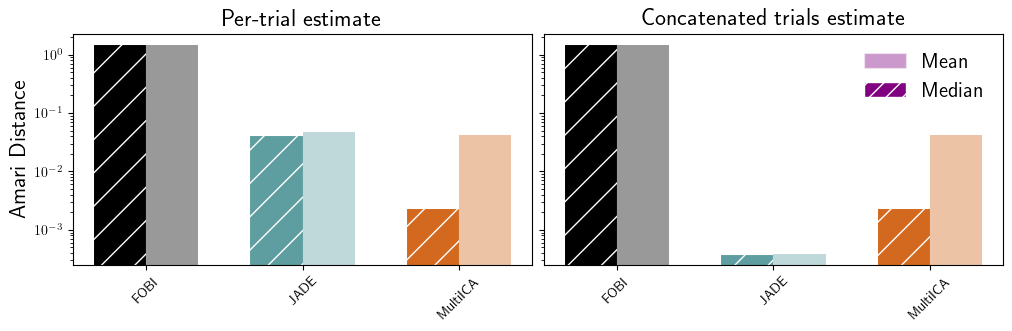

In [12]:
scale = 3

fig, axes = plt.subplots(1, 2, figsize=(4 * scale, 1 * scale), sharey=True)
create_ax_per_trial(axes[0])
create_ax_concatenation(axes[1])
for ax in axes:
    ax.set_ylabel("Amari Distance")
    ax.set_yscale("log")
    ax.label_outer()
plt.subplots_adjust(wspace=0.025)
plt.savefig(f"../figures/baselines_bar.pdf", bbox_inches="tight")
plt.show()